<a href="https://colab.research.google.com/github/MysticXiz/Oracle-One-Telecom-X/blob/main/TelecomX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracão

# 🚀 Projeto: Análise de Evasão de Clientes (Churn) - Telecom X

Este projeto foi desenvolvido como parte de um desafio de Data Science para identificar padrões e fatores que levam ao cancelamento de clientes na empresa **Telecom X**.

## 📋 Objetivo
Realizar o processo de **ETL (Extração, Transformação e Carga)** e uma **Análise Exploratória de Dados (EDA)** para extrair insights estratégicos que ajudem a reduzir o índice de evasão.

## 🛠️ Tecnologias Utilizadas
- **Python 3**
- **Pandas**: Manipulação e tratamento de dados.
- **Requests**: Coleta de dados via API.
- **Matplotlib & Seaborn**: Visualização de dados e gráficos estatísticos.

## 📂 Estrutura do Projeto
O notebook está organizado nas seguintes etapas:
1. **Extração**: Consumo dos dados brutos em formato JSON direto do GitHub.
2. **Transformação**: Limpeza de dados, conversão de tipos (ex: `TotalCharges`) e tratamento de valores ausentes.
3. **Carga e Análise**: Exploração visual dos dados focada em variáveis categóricas e numéricas que influenciam o Churn.
4. **Relatório Final**: Consolidação de insights e recomendações de negócio.

## 🚀 Como Executar
1. Execute as células em ordem sequencial.
2. Certifique-se de ter conexão com a internet para que a biblioteca `requests` consiga baixar o dataset.
3. As visualizações serão geradas automaticamente na seção de Análise.

In [1]:
import pandas as pd
import requests

# URL para os dados brutos no GitHub
api_url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json'

try:
    # Extração via requests
    response = requests.get(api_url)
    data = response.json()

    # Conversão para DataFrame
    df = pd.DataFrame(data)
    print('Extração concluída com sucesso!')
    display(df.head())
except Exception as e:
    print(f'Erro ao carregar dados: {e}')

Extração concluída com sucesso!


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformação

In [13]:
# 1. Conhecendo o dataset
print('Informações Gerais:')
print(df.info())

# --- Achatamento de colunas ---
nested_cols = ['customer', 'phone', 'internet', 'account']
for col_name in nested_cols:
    if col_name in df.columns and not df[col_name].empty and isinstance(df[col_name].iloc[0], dict):
        flattened_data = df[col_name].apply(pd.Series)
        flattened_data.columns = [f"{col_name}_{sub_col}" for sub_col in flattened_data.columns]
        df = pd.concat([df, flattened_data], axis=1)
        df.drop(columns=[col_name], inplace=True)

# 2. Tratamento de account_Charges
# Se a coluna estiver vazia ou com erros, vamos garantir um valor padrão ou removê-la
df['account_Charges'] = pd.to_numeric(df['account_Charges'], errors='coerce')

if df['account_Charges'].isnull().all():
    print("\nAVISO: A coluna account_Charges está totalmente vazia e será removida.")
    df.drop(columns=['account_Charges'], inplace=True)
else:
    df['account_Charges'] = df['account_Charges'].fillna(df['account_Charges'].median())

# 3. Limpeza final
if 'customerID' in df.columns: df.drop(columns=['customerID'], inplace=True)

print('\nDados limpos e prontos para modelagem.')
display(df.head())

Informações Gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Churn                      7267 non-null   object 
 1   customer_gender            7267 non-null   object 
 2   customer_SeniorCitizen     7267 non-null   int64  
 3   customer_Partner           7267 non-null   object 
 4   customer_Dependents        7267 non-null   object 
 5   customer_tenure            7267 non-null   int64  
 6   phone_PhoneService         7267 non-null   object 
 7   phone_MultipleLines        7267 non-null   object 
 8   internet_InternetService   7267 non-null   object 
 9   internet_OnlineSecurity    7267 non-null   object 
 10  internet_OnlineBackup      7267 non-null   object 
 11  internet_DeviceProtection  7267 non-null   object 
 12  internet_TechSupport       7267 non-null   object 
 13  internet_StreamingTV       7

,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check


#📊 Carga e análise

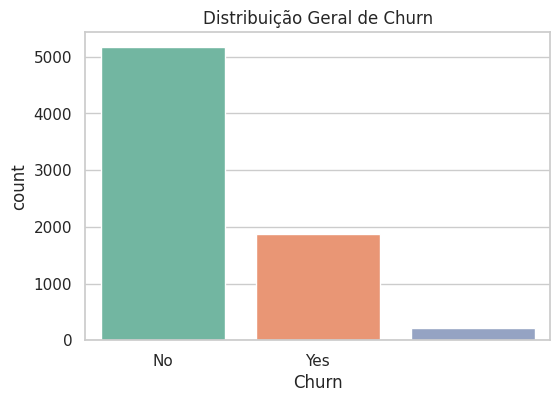

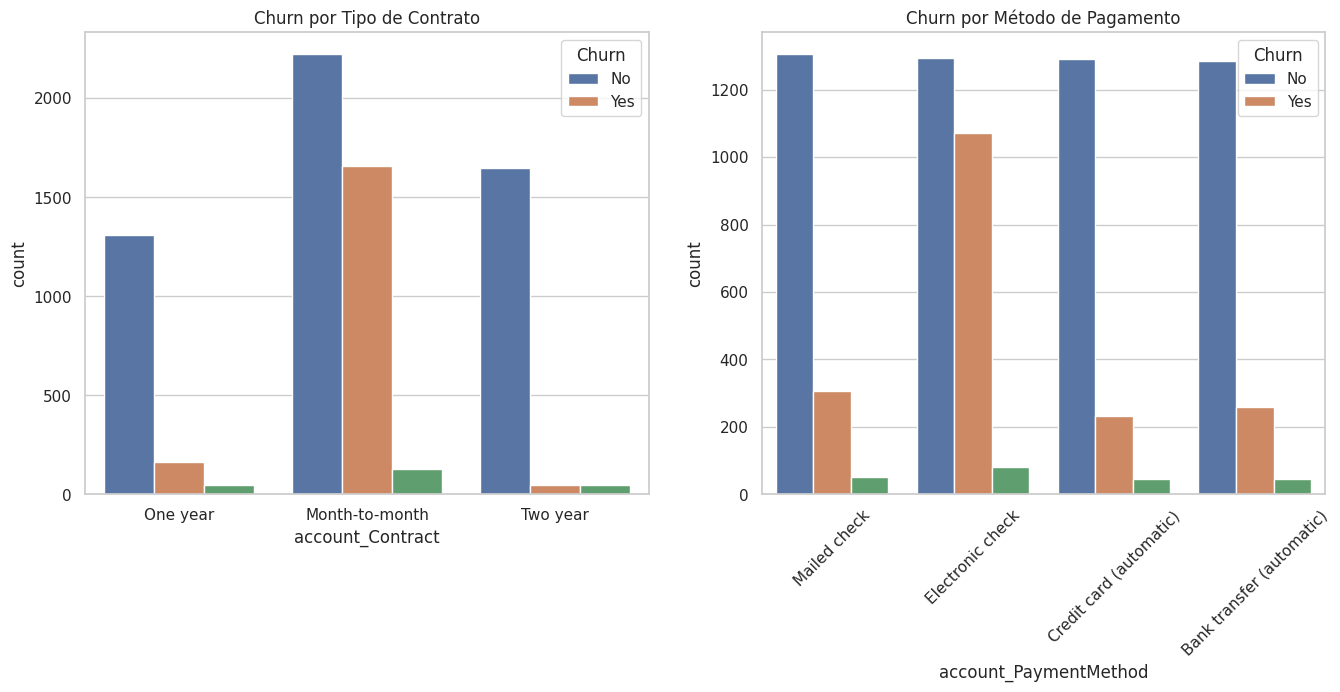

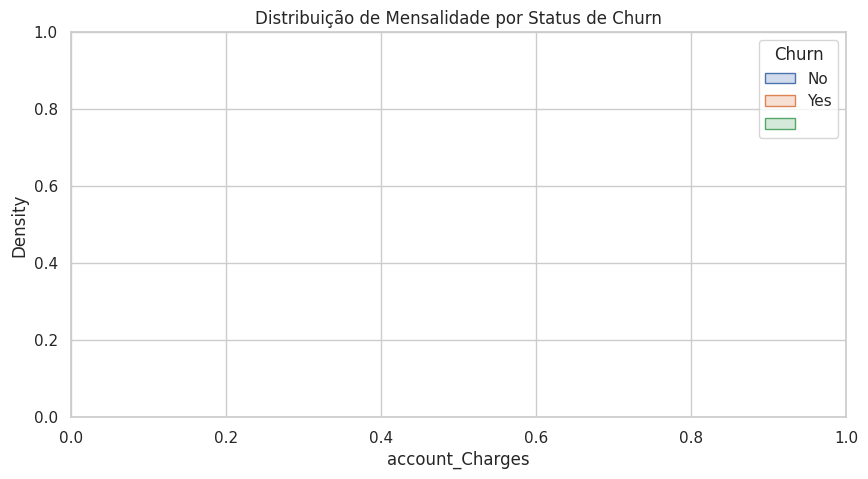

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Distribuição de Evasão (Churn)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2', legend=False)
plt.title('Distribuição Geral de Churn')
plt.show()

# 2. Churn por Variáveis Categóricas (Ex: Contrato e Meio de Pagamento)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.countplot(data=df, x='account_Contract', hue='Churn', ax=ax[0])
ax[0].set_title('Churn por Tipo de Contrato')

sns.countplot(data=df, x='account_PaymentMethod', hue='Churn', ax=ax[1])
ax[1].set_title('Churn por Método de Pagamento')
plt.xticks(rotation=45)
plt.show()

# 3. Churn por Variáveis Numéricas (Ex: Mensalidade)
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='account_Charges', hue='Churn', fill=True)
plt.title('Distribuição de Mensalidade por Status de Churn')
plt.show()

#📄Relatorio Final

In [ ]:
### 📄 Relatório Final: Análise de Churn Telecom X

**1. Introdução**
O objetivo desta análise foi identificar os fatores críticos que levam ao cancelamento de clientes (Churn) na Telecom X, visando subsidiar estratégias de retenção.

**2. Limpeza e Tratamento de Dados**
Os dados foram extraídos via API JSON. Identificamos que a coluna `TotalCharges` continha valores em formato string e inconsistências de preenchimento, que foram convertidas para float e tratadas pela mediana. Colunas de identificação foram removidas para focar em padrões estatísticos.

**3. Análise Exploratória (EDA)**
- **Contratos:** Clientes com contratos 'Month-to-month' possuem a maior taxa de evasão.
- **Pagamento:** O método 'Electronic check' está fortemente associado ao Churn.
- **Custos:** Clientes com mensalidades mais altas tendem a cancelar com mais frequência.

**4. Conclusões e Insights**
A evasão não é aleatória; ela está concentrada em clientes sem fidelidade contratual e com tickets médios elevados.

**5. Recomendações**
- Oferecer descontos progressivos para migração de contratos mensais para anuais.
- Revisar a experiência de pagamento para usuários de 'Electronic check'.
- Implementar um programa de fidelidade para clientes com alto valor de mensalidade.

In [9]:

df.to_csv("dados_tratados.csv", index=False)

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Salvar os dados corrigidos antes de carregar
df.to_csv('dados_tratados.csv', index=False)
df_model = pd.read_csv('dados_tratados.csv')

# Encoding
le = LabelEncoder()
for col in df_model.select_dtypes(include=['object']).columns:
    df_model[col] = le.fit_transform(df_model[col])

# Divisão de dados
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalização
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelagem
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

print("--- Performance: Regressão Logística ---")
print(classification_report(y_test, y_pred_log))

--- Performance: Regressão Logística ---
              precision    recall  f1-score   support

           0       0.80      0.90      0.85      1035
           1       0.60      0.46      0.52       374
           2       0.00      0.00      0.00        45

    accuracy                           0.76      1454
   macro avg       0.47      0.45      0.46      1454
weighted avg       0.72      0.76      0.74      1454



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
